# About This notebook

This notebook imports data from the `stage_00` schema from the PostgreSQL database `train_reward_compare`. The data in this schema was created in an earlier notebook in this series.

The notebook performs exploratory data analysis on the imported data.

When finished, the notebook inserts the data into the next schema: `stage_01`.

## Links to Data

[https://www.onetcenter.org/database.html#all-files](https://www.onetcenter.org/database.html#all-files)

[https://www.bls.gov/oes/](https://www.bls.gov/oes/)

# Project Setup

## Import and Verifications

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sqlalchemy

In [2]:
print(sqlalchemy.__version__)

2.0.48


In [3]:
from sqlalchemy import create_engine, inspect
from sqlalchemy import text
from sqlalchemy.schema import CreateSchema
from sqlalchemy import BigInteger, Column, Integer, String, Float, Boolean, Text, Date
from sqlalchemy.orm import DeclarativeBase, Mapped, mapped_column

In [4]:
# The following imports are a match from the previous Springboard EDA project

import statsmodels.api as sm
from statsmodels.graphics.api import abline_plot
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn import linear_model, preprocessing
import warnings
 
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.filterwarnings(action="ignore", module="scipy", message="^internal gelsd")

## Create SQL Engine and Test Connection

In [5]:
engine = create_engine('postgresql+psycopg2://postgres@localhost/train_reward_compare')

In [6]:
with engine.connect() as conn:
    result = conn.execute(text("select count(*) from onet.occupation_data"))
    print(result.fetchone())

(1016,)


# Import Data from PostgreSQL

## List of Imports

We start by bringing the previous datasets stored in the `stage_00` schema.

- bls_nat_data
- bls_nat_desc
- onet_ete
- onet_ete_categories
- onet_occupation_data
- onet_content_model_reference
- onet_scales_reference

## Import All Datasets

In [7]:
# Data Schema for Import
schema_name_import = 'stage_00'

# Data Table Names
bls_nat_data_table_name = 'bls_nat_data'
bls_nat_desc_table_name = 'bls_nat_desc'
onet_ete_table_name = 'onet_ete'
onet_ete_categories_table_name = 'onet_ete_categories'
onet_occupation_data_table_name = 'onet_occupation_data'
onet_content_model_reference_table_name = 'onet_content_model_reference'
onet_scales_reference_table_name = 'onet_scales_reference'

In [8]:
nat_data = pd.DataFrame()

with engine.connect() as conn:
    nat_data = pd.read_sql_table(bls_nat_data_table_name, schema=schema_name_import, con=engine, index_col='id')

In [9]:
nat_desc = pd.DataFrame()

with engine.connect() as conn:
    nat_desc = pd.read_sql_table(bls_nat_desc_table_name, schema=schema_name_import, con=engine, index_col='id')

In [10]:
ete = pd.DataFrame()

with engine.connect() as conn:
    ete = pd.read_sql_table(onet_ete_table_name, schema=schema_name_import, con=engine, index_col='id')

In [11]:
ete_categories = pd.DataFrame()

with engine.connect() as conn:
    ete_categories = pd.read_sql_table(onet_ete_categories_table_name, schema=schema_name_import, con=engine, index_col='id')

In [12]:
occupation_data = pd.DataFrame()

with engine.connect() as conn:
    occupation_data = pd.read_sql_table(onet_occupation_data_table_name, schema=schema_name_import, con=engine, index_col='id')

In [13]:
content_model_reference = pd.DataFrame()

with engine.connect() as conn:
    content_model_reference = pd.read_sql_table(onet_content_model_reference_table_name, schema=schema_name_import, con=engine, index_col='id')

In [14]:
scales_reference = pd.DataFrame()

with engine.connect() as conn:
    scales_reference = pd.read_sql_table(onet_scales_reference_table_name, schema=schema_name_import, con=engine, index_col='id')

# Initial Explorations

## Analyzing BLS `nat_data`

In [15]:
nat_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1070 entries, 1 to 1070
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   area         1070 non-null   int64  
 1   area_title   1070 non-null   object 
 2   area_type    1070 non-null   int64  
 3   prim_state   1070 non-null   object 
 4   naics        1070 non-null   int64  
 5   naics_title  1070 non-null   object 
 6   i_group      1070 non-null   object 
 7   own_code     1070 non-null   int64  
 8   occ_code     1070 non-null   object 
 9   occ_title    1070 non-null   object 
 10  o_group      1070 non-null   object 
 11  tot_emp      1070 non-null   int64  
 12  emp_prse     1070 non-null   float64
 13  h_mean       992 non-null    float64
 14  a_mean       1063 non-null   float64
 15  mean_prse    1070 non-null   float64
 16  h_pct10      992 non-null    float64
 17  h_pct25      992 non-null    float64
 18  h_median     992 non-null    float64
 19  h_pct75    

In [16]:
nat_data.head(2)

,area,area_title,area_type,prim_state,naics,naics_title,i_group,own_code,occ_code,occ_title,...,h_median,h_pct75,h_pct90,a_pct10,a_pct25,a_median,a_pct75,a_pct90,annual,hourly
id,,,,,,,,,,,,,,,,,,,,,
1,99,U.S.,1,US,0,Cross-industry,cross-industry,1235,00-0000,All Occupations,...,23.8,37.89,60.44,29990.0,36730.0,49500.0,78810.0,125720.0,None,None
2,99,U.S.,1,US,0,Cross-industry,cross-industry,1235,11-0000,Management Occupations,...,58.7,82.50,115.00,57010.0,79900.0,122090.0,171610.0,239200.0,None,None


In [17]:
nat_data.nunique()

area              1
area_title        1
area_type         1
prim_state        1
naics             1
naics_title       1
i_group           1
own_code          1
occ_code       1070
occ_title      1070
o_group           5
tot_emp        1041
emp_prse        130
h_mean          880
a_mean          996
mean_prse        74
h_pct10         747
h_pct25         802
h_median        814
h_pct75         879
h_pct90         850
a_pct10         897
a_pct25         939
a_median        945
a_pct75         991
a_pct90         954
annual            1
hourly            1
dtype: int64

In [18]:
nat_desc.iloc[:10,:]

,field,field_description
id,,
1,area,"U.S. (99), state FIPS code, Metropolitan Stati..."
2,area_title,Area name
3,area_type,Area type: 1= U.S.; 2= State; 3= U.S. Territor...
4,prim_state,"The primary state for the given area. ""US"" is ..."
5,naics,North American Industry Classification System ...
6,naics_title,North American Industry Classification System ...
7,i_group,Industry level. Indicates cross-industry or NA...
8,own_code,Ownership type: 1= Federal Government; 2= Stat...
9,occ_code,The 6-digit Standard Occupational Classificati...


### Dropping Unnecessary Columns

Let's go ahead and drop those columns that are out of our scope at this time.

In [19]:
nat_data = nat_data.drop(columns=[
    'area',
    'area_title',
    'area_type',
    'prim_state',
    'naics',
    'naics_title',
    'i_group',
    'own_code'
])

### BLS : Separating Overlapping Rows

A simple boxplot shows that we have a problem.

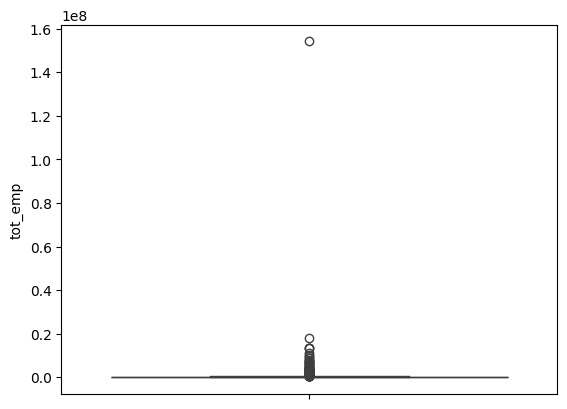

In [20]:
fig, ax = plt.subplots()
_ = sns.boxplot(data=nat_data, y='tot_emp')
plt.show()

In [21]:
nat_data.head(5)

,occ_code,occ_title,o_group,tot_emp,emp_prse,h_mean,a_mean,mean_prse,h_pct10,h_pct25,h_median,h_pct75,h_pct90,a_pct10,a_pct25,a_median,a_pct75,a_pct90,annual,hourly
id,,,,,,,,,,,,,,,,,,,,
1,00-0000,All Occupations,total,154187380,0.0,32.66,67920.0,0.1,14.42,17.66,23.80,37.89,60.44,29990.0,36730.0,49500.0,78810.0,125720.0,None,None
2,11-0000,Management Occupations,major,10966830,0.2,68.15,141760.0,0.2,27.41,38.42,58.70,82.50,115.00,57010.0,79900.0,122090.0,171610.0,239200.0,None,None
3,11-1000,Top Executives,minor,3822780,0.3,67.24,139860.0,0.4,22.84,33.08,50.48,81.01,115.00,47510.0,68800.0,104990.0,168490.0,239200.0,None,None
4,11-1010,Chief Executives,broad,211850,1.2,126.41,262930.0,0.9,35.44,60.61,99.24,115.00,115.00,73710.0,126080.0,206420.0,239200.0,239200.0,None,None
5,11-1020,General and Operations Managers,broad,3584420,0.4,64.00,133120.0,0.4,22.80,32.29,49.50,78.91,115.00,47420.0,67160.0,102950.0,164130.0,239200.0,None,None


This data is overlapping. For example, note that at the top of the df, there is a row that has the total value of all other rows combined. 

Observe what happens when we turn off outliers.

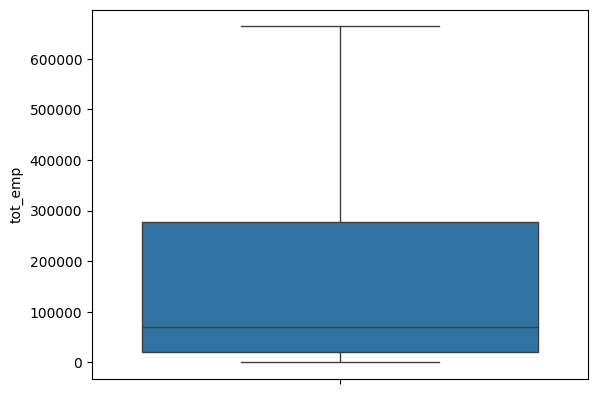

In [22]:
fig, ax = plt.subplots()
_ = sns.boxplot(data=nat_data, y='tot_emp', showfliers=False)
plt.show()

How far down does the data overlap, and what is the best way to separate the data to perform observation?

Let's start with the `o_group` column.

In [23]:
nat_data['o_group'].value_counts()

o_group
detailed    549
broad       412
minor        86
major        22
total         1
Name: count, dtype: int64

Let's check that the `total` is equal to the value of all of the `major` groups combined, using `tot_emp` as our target.

In [24]:
total_summary_nat_data = nat_data[nat_data['o_group'] == 'total']

In [25]:
a = np.sum(total_summary_nat_data['tot_emp'])
print(a)

154187380


In [26]:
major_summary_nat_data = nat_data[nat_data['o_group'] == 'major']

In [27]:
b = np.sum(major_summary_nat_data['tot_emp'])
print(b)

154187380


##### Commentary

This is correct. The `total` `o_group` is a collection of all of the `major` groups. 

Let's extend to the `minor` groups.

In [28]:
minor_summary_nat_data = nat_data[nat_data['o_group'] == 'minor']

In [29]:
c = np.sum(minor_summary_nat_data['tot_emp'])

In [30]:
print(c)

148322660


Apparently, this does not extend to the `minor` group. Perhaps the `minor` group compliments some of the other available groups. Or, perhaps some of the `major` groups do not have any `minor` groups, and maybe even some `major` groups only have `broad` or `detailed` groups. 

In [31]:
broad_summary_nat_data = nat_data[nat_data['o_group'] == 'broad']
d = np.sum(broad_summary_nat_data['tot_emp'])
print(d)

135852990


In [32]:
detailed_summary_nat_data = nat_data[nat_data['o_group'] == 'detailed']
e = np.sum(detailed_summary_nat_data['tot_emp'])
print(e)

75538550


Clearly, there is overlap and continued duplicate values.

We won't be able to simply run tests on the entire dataset as a whole. We'll need to select a subgroup and focus on that.

In [33]:
with pd.option_context('display.max_rows', None):
    print(major_summary_nat_data[['occ_code', 'occ_title']])

     occ_code                                          occ_title
id                                                              
2     11-0000                             Management Occupations
50    13-0000      Business and Financial Operations Occupations
89    15-0000              Computer and Mathematical Occupations
115   17-0000           Architecture and Engineering Occupations
160   19-0000     Life, Physical, and Social Science Occupations
224   21-0000           Community and Social Service Occupations
246   23-0000                                  Legal Occupations
260   25-0000    Educational Instruction and Library Occupations
344   27-0000  Arts, Design, Entertainment, Sports, and Media...
399   29-0000  Healthcare Practitioners and Technical Occupat...
484   31-0000                     Healthcare Support Occupations
509   33-0000                     Protective Service Occupations
545   35-0000   Food Preparation and Serving Related Occupations
567   37-0000  Building a

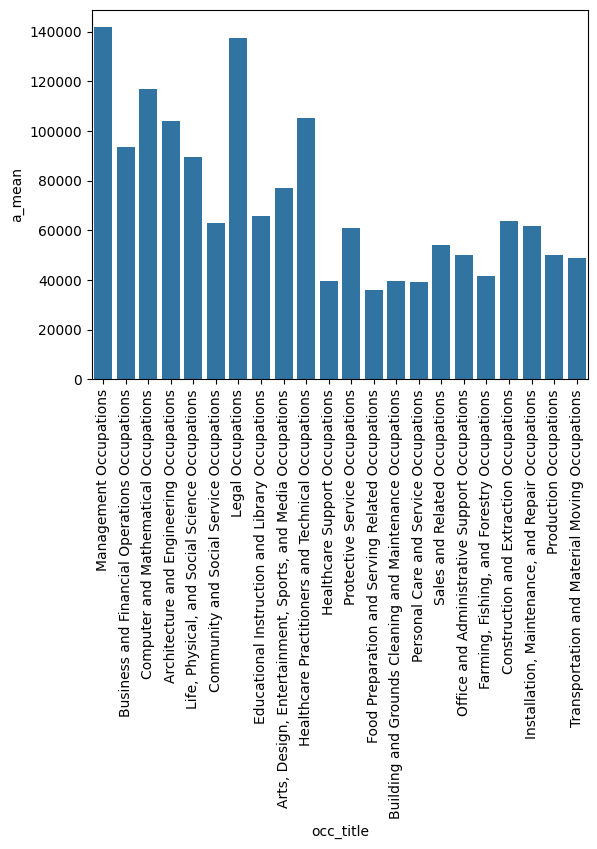

In [34]:
fig, ax = plt.subplots()
_ = sns.barplot(data=major_summary_nat_data, x='occ_title', y='a_mean')
_ = plt.xticks(rotation=90)
plt.show()

From this barplot, we can see a general overview of the different industries.

Management and Legal professions dominate.

Food Preparation and Healthcare Support trail at the bottom.

### Explorating Education as a Subgroup

To better understand the dataset, let's choose one specific `major` area and see how the subgroups align within it.

In my current daytime job, I am a school teacher. This field requires significant training in the form of advanced degress and certificates, so it is a useful area to explore as part of our primary research objective.

Let's look at the `Educational Instruction and Library Occupations` sections.

In [35]:
edu_summary_nat_data = nat_data[nat_data['occ_code'].str.startswith('25') == True]

In [36]:
edu_summary_nat_data.head(7)

,occ_code,occ_title,o_group,tot_emp,emp_prse,h_mean,a_mean,mean_prse,h_pct10,h_pct25,h_median,h_pct75,h_pct90,a_pct10,a_pct25,a_median,a_pct75,a_pct90,annual,hourly
id,,,,,,,,,,,,,,,,,,,,
260,25-0000,Educational Instruction and Library Occupations,major,8947710,0.1,31.69,65900.0,0.5,14.81,19.17,28.47,37.62,50.17,30790.0,39870.0,59220.0,78250.0,104360.0,None,None
261,25-1000,Postsecondary Teachers,minor,1396300,0.2,NaN,102410.0,0.5,NaN,NaN,NaN,NaN,NaN,47010.0,61300.0,81600.0,125900.0,180630.0,True,None
262,25-1010,"Business Teachers, Postsecondary",broad,81780,0.7,NaN,113840.0,0.6,NaN,NaN,NaN,NaN,NaN,46460.0,63040.0,97270.0,140360.0,210530.0,True,None
263,25-1020,"Math and Computer Science Teachers, Postsecondary",broad,85060,0.3,NaN,98400.0,0.6,NaN,NaN,NaN,NaN,NaN,48470.0,62160.0,82390.0,124840.0,168080.0,True,None
264,25-1021,"Computer Science Teachers, Postsecondary",detailed,36240,0.6,NaN,105830.0,0.7,NaN,NaN,NaN,NaN,NaN,48910.0,65200.0,96690.0,132200.0,172380.0,True,None
265,25-1022,"Mathematical Science Teachers, Postsecondary",detailed,48820,0.3,NaN,92880.0,0.6,NaN,NaN,NaN,NaN,NaN,48150.0,60880.0,79350.0,106270.0,161020.0,True,None
266,25-1030,"Engineering and Architecture Teachers, Postsec...",broad,49030,0.5,NaN,117670.0,0.6,NaN,NaN,NaN,NaN,NaN,59690.0,79300.0,105690.0,135710.0,184300.0,True,None


In [37]:
edu_summary_nat_data.shape

(84, 20)

We can see here that the `occ_code` rows that have a variant of `25-102X` are all similar. One is `broad`; the other two are `detailed`.

Do the two `detailed` values add up to the `broad` value?

In [38]:
a = edu_summary_nat_data[edu_summary_nat_data['occ_code'] == '25-1020']['tot_emp'].iloc[0]
b = edu_summary_nat_data[edu_summary_nat_data['occ_code'] == '25-1021']['tot_emp'].iloc[0]
c = edu_summary_nat_data[edu_summary_nat_data['occ_code'] == '25-1022']['tot_emp'].iloc[0]
print(a == b + c)

True


We now know more about how our data is structured.

At least some of the `broad` groups are composed of `detailed` group subsets.

The `occ_code` column is our primary clue to factoring this information.

In [39]:
edu_summary_nat_data[edu_summary_nat_data['occ_code'].str.endswith('00') == True]

,occ_code,occ_title,o_group,tot_emp,emp_prse,h_mean,a_mean,mean_prse,h_pct10,h_pct25,h_median,h_pct75,h_pct90,a_pct10,a_pct25,a_median,a_pct75,a_pct90,annual,hourly
id,,,,,,,,,,,,,,,,,,,,
260,25-0000,Educational Instruction and Library Occupations,major,8947710,0.1,31.69,65900.0,0.5,14.81,19.17,28.47,37.62,50.17,30790.0,39870.0,59220.0,78250.0,104360.0,None,None
261,25-1000,Postsecondary Teachers,minor,1396300,0.2,NaN,102410.0,0.5,NaN,NaN,NaN,NaN,NaN,47010.0,61300.0,81600.0,125900.0,180630.0,True,None
309,25-2000,"Preschool, Elementary, Middle, Secondary, and ...",minor,4321590,0.3,NaN,68130.0,0.5,NaN,NaN,NaN,NaN,NaN,39620.0,49540.0,61960.0,79020.0,101290.0,True,None
326,25-3000,Other Teachers and Instructors,minor,1125750,0.9,24.65,51270.0,0.7,13.49,16.35,21.26,28.78,38.98,28070.0,34010.0,44220.0,59860.0,81070.0,None,None
331,25-4000,"Librarians, Curators, and Archivists",minor,238010,0.9,28.95,60220.0,0.5,15.19,19.43,27.45,35.96,46.17,31600.0,40410.0,57100.0,74800.0,96030.0,None,None
338,25-9000,Other Educational Instruction and Library Occu...,minor,1866060,0.4,NaN,42980.0,0.5,NaN,NaN,NaN,NaN,NaN,24960.0,30140.0,36690.0,47800.0,69330.0,True,None


In [40]:
temp_minor_focus = edu_summary_nat_data[(edu_summary_nat_data['occ_code'].str.endswith('00') == True) & (edu_summary_nat_data['o_group'] == 'minor')]

In [41]:
a = edu_summary_nat_data[edu_summary_nat_data['o_group'] == 'major']['tot_emp'].iloc[0]

In [42]:
b = np.sum(temp_minor_focus['tot_emp'])

In [43]:
print(a)
print(b)

8947710
8947710


At least in the Educational occupation, the `minor` subgroups collectively match the total of the `major` subgroup.

Let's drill down further into teachers.

In [44]:
temp_edu_focus = edu_summary_nat_data[edu_summary_nat_data['occ_code'].str.startswith('25-2') == True]
temp_edu_focus.head(20)

,occ_code,occ_title,o_group,tot_emp,emp_prse,h_mean,a_mean,mean_prse,h_pct10,h_pct25,h_median,h_pct75,h_pct90,a_pct10,a_pct25,a_median,a_pct75,a_pct90,annual,hourly
id,,,,,,,,,,,,,,,,,,,,
309,25-2000,"Preschool, Elementary, Middle, Secondary, and ...",minor,4321590,0.3,NaN,68130.0,0.5,NaN,NaN,NaN,NaN,NaN,39620.0,49540.0,61960.0,79020.0,101290.0,True,None
310,25-2010,Preschool and Kindergarten Teachers,broad,559490,1.1,22.44,46680.0,0.7,13.85,16.56,19.27,26.82,35.28,28810.0,34440.0,40090.0,55780.0,73380.0,None,None
311,25-2011,"Preschool Teachers, Except Special Education",detailed,445080,1.4,19.93,41450.0,0.7,13.61,15.03,17.85,22.38,28.88,28300.0,31250.0,37120.0,46550.0,60070.0,None,None
312,25-2012,"Kindergarten Teachers, Except Special Education",detailed,114410,1.4,NaN,67020.0,0.7,NaN,NaN,NaN,NaN,NaN,45750.0,50290.0,61430.0,77720.0,99360.0,True,None
313,25-2020,Elementary and Middle School Teachers,broad,2027880,0.5,NaN,69860.0,0.6,NaN,NaN,NaN,NaN,NaN,46620.0,51140.0,62500.0,79400.0,101670.0,True,None
314,25-2021,"Elementary School Teachers, Except Special Edu...",detailed,1393310,0.8,NaN,69790.0,0.6,NaN,NaN,NaN,NaN,NaN,46440.0,50680.0,62340.0,79410.0,102010.0,True,None
315,25-2022,"Middle School Teachers, Except Special and Car...",detailed,620370,1.5,NaN,70040.0,0.8,NaN,NaN,NaN,NaN,NaN,47050.0,53540.0,62970.0,79380.0,100980.0,True,None
316,25-2023,"Career/Technical Education Teachers, Middle Sc...",detailed,14200,3.6,NaN,68690.0,1.3,NaN,NaN,NaN,NaN,NaN,47090.0,55920.0,63620.0,78270.0,98430.0,True,None
317,25-2030,Secondary School Teachers,broad,1176990,0.9,NaN,73420.0,0.6,NaN,NaN,NaN,NaN,NaN,47460.0,57950.0,64530.0,82340.0,103860.0,True,None


In [45]:
a = temp_edu_focus['tot_emp'].iloc[0]
print(a)

4321590


In [46]:
b = np.sum(temp_edu_focus[temp_edu_focus['o_group'] == 'broad']['tot_emp'])
print(b)

4321600


They almost match, but not quite. 

There are `10` more people in the `broad` category than in the overarching `minor` category. 

### Creating Functions to Explore Overlapping Data

#### Parsing `broad` and `detailed`

Let's write a simple function that tests whether the `tot_emp` value of a `broad` category matches the sum of the following `detailed` categories.

In [47]:
def test_broad_detailed_sum(df_nat_data, o_group_broad):
    
    # Set a temporary df for simplicity
    temp_df = df_nat_data[df_nat_data['occ_code'].str[:-1] == o_group_broad[:-1]]
    temp_df.reset_index(drop=True)

    # Test temp_df formation
    if len(temp_df) == 0:
        print('Failed to parse dataframe')
        return False

    print(f"# of rows to test for {o_group_broad}: {len(temp_df)}")
    
    # Find the value of the tot_emp broad group 
    a = temp_df['tot_emp'].iloc[0]
    print(f"Broad group {temp_df['occ_code'].iloc[0]} tot_emp: {a}")  
    
    # Find the sum of all of the  tot_emp for the following groups
    b = 0
    digits_1_9 = tuple(str(i) for i in range(1, 10))
    for i in range(len(temp_df)):
        if temp_df['occ_code'].iloc[i].endswith(digits_1_9):
            # print(f"Subgroup: {temp_df['occ_code'].iloc[i]}, adding tot_emp: {temp_df['tot_emp'].iloc[i]}")
            b += temp_df['tot_emp'].iloc[i]
    
    print(f"Detailed groups of {temp_df['occ_code'].iloc[0]} tot_emp: {b}")
    print(f"Difference: {a - b}")
    print(a == b)

In [48]:
temp_broad_occ_codes = temp_edu_focus[temp_edu_focus['o_group'] == 'broad']['occ_code']

In [49]:
temp_broad_occ_codes

id
310    25-2010
313    25-2020
317    25-2030
320    25-2050
Name: occ_code, dtype: object

In [50]:
for i in range(len(temp_broad_occ_codes)):
    print(f"\n\nTesting: {temp_broad_occ_codes.iloc[i]}")
    test_broad_detailed_sum(temp_edu_focus, temp_broad_occ_codes.iloc[i])



Testing: 25-2010
# of rows to test for 25-2010: 3
Broad group 25-2010 tot_emp: 559490
Detailed groups of 25-2010 tot_emp: 559490
Difference: 0
True


Testing: 25-2020
# of rows to test for 25-2020: 4
Broad group 25-2020 tot_emp: 2027880
Detailed groups of 25-2020 tot_emp: 2027880
Difference: 0
True


Testing: 25-2030
# of rows to test for 25-2030: 3
Broad group 25-2030 tot_emp: 1176990
Detailed groups of 25-2030 tot_emp: 1176990
Difference: 0
True


Testing: 25-2050
# of rows to test for 25-2050: 6
Broad group 25-2050 tot_emp: 557240
Detailed groups of 25-2050 tot_emp: 557230
Difference: 10
False


##### Commentary

There are `10` `tot_emp` values missing in the Special Education category.

This seems to be the solution to the puzzle. Somehow, there were `10` values to `tot_emp` added to the `broad` category for special-education teacher, but these extra `10` values were not included in the wider `minor` category.

Therefore, in theory, the `detailed` total should add up to the `minor` total.

In [51]:
print(a)

4321590


In [52]:
b = np.sum(temp_edu_focus[temp_edu_focus['o_group'] == 'detailed']['tot_emp'])
print(b)

4321590


Our theory is correct.

The `minor` category is inaccurate by `10` values for an unknown reason.

In this one `minor` area, we can use the `detailed` rows and thereby capture a reasonably accurate view of the population sample.

#### Parsing `minor` and `broad`

Currently, we are looking at all `broad` groups within `minor` area, as defined by `25-2`.

Let's try expanding this to apply to all `minor` areas within the major area, and maybe we can later expand to all major areas as well.

In [53]:
temp_df_minor_within_major = nat_data[(nat_data['occ_code'].str.startswith('25-') == True) & (nat_data['o_group'] == 'minor')]

In [54]:
temp_df_minor_within_major.head()

,occ_code,occ_title,o_group,tot_emp,emp_prse,h_mean,a_mean,mean_prse,h_pct10,h_pct25,h_median,h_pct75,h_pct90,a_pct10,a_pct25,a_median,a_pct75,a_pct90,annual,hourly
id,,,,,,,,,,,,,,,,,,,,
261,25-1000,Postsecondary Teachers,minor,1396300,0.2,NaN,102410.0,0.5,NaN,NaN,NaN,NaN,NaN,47010.0,61300.0,81600.0,125900.0,180630.0,True,None
309,25-2000,"Preschool, Elementary, Middle, Secondary, and ...",minor,4321590,0.3,NaN,68130.0,0.5,NaN,NaN,NaN,NaN,NaN,39620.0,49540.0,61960.0,79020.0,101290.0,True,None
326,25-3000,Other Teachers and Instructors,minor,1125750,0.9,24.65,51270.0,0.7,13.49,16.35,21.26,28.78,38.98,28070.0,34010.0,44220.0,59860.0,81070.0,None,None
331,25-4000,"Librarians, Curators, and Archivists",minor,238010,0.9,28.95,60220.0,0.5,15.19,19.43,27.45,35.96,46.17,31600.0,40410.0,57100.0,74800.0,96030.0,None,None
338,25-9000,Other Educational Instruction and Library Occu...,minor,1866060,0.4,NaN,42980.0,0.5,NaN,NaN,NaN,NaN,NaN,24960.0,30140.0,36690.0,47800.0,69330.0,True,None


In [55]:
temp_df_minor_within_major.shape

(5, 20)

We have a total of `5` `minor` subgroups within the `major` area of education.

In [56]:
temp_list_minor = temp_df_minor_within_major['occ_code']

In [57]:
def apply_within_major(df, major_occ_code, func):
    temp_df_major = df[df['occ_code'].str[:3] == major_occ_code[:3]]
    temp_df_major.reset_index(drop=True)

    if len(temp_df_major) == 0:
        print('Failed to parse dataframe')
        return False

    # Print to console current status
    print(f"# of rows with major {major_occ_code}: {len(temp_df_major)}")

    # Create df of minor groups
    temp_minor_occ_codes = temp_df_major[(temp_df_major['occ_code'].str.startswith(major_occ_code[:3]) == True) & (temp_df_major['o_group'] == 'minor')]['occ_code']
    print(f"# of minor subgroups: {len(temp_minor_occ_codes)}")
    
    # Apply function to each minor group
    for i in range(len(temp_minor_occ_codes)):
        print(f"\nTesting minor group: {temp_minor_occ_codes.iloc[i]}")
        print(f"Title: {temp_df_major[temp_df_major['occ_code'] == temp_minor_occ_codes.iloc[i]]['occ_title'].item()}")

        # Come up with a temp_minor_df
        temp_df_minor = temp_df_major[temp_df_major['occ_code'].str[:5] == temp_minor_occ_codes.iloc[i][:5]]
        print(f"# of rows within minor group: {len(temp_df_minor)}")
        
        # Come up with broad codes within this group
        temp_broad_occ_codes = temp_df_minor[temp_df_minor['o_group'] == 'broad']['occ_code']
            
        # Pass the major df and the broad codes to the func
        for i in range(len(temp_broad_occ_codes)):
            print(f"\n\nTesting: {temp_broad_occ_codes.iloc[i]}")
            print(f"Title: {temp_df_minor[temp_df_minor['occ_code'] == temp_broad_occ_codes.iloc[i]]['occ_title'].item()}")
            func(temp_df_minor, temp_broad_occ_codes.iloc[i])

In [58]:
apply_within_major(nat_data, '25-0000', test_broad_detailed_sum)

# of rows with major 25-0000: 84
# of minor subgroups: 5

Testing minor group: 25-1000
Title: Postsecondary Teachers
# of rows within minor group: 32


Testing: 25-1010
Title: Business Teachers, Postsecondary
# of rows to test for 25-1010: 1
Broad group 25-1010 tot_emp: 81780
Detailed groups of 25-1010 tot_emp: 0
Difference: 81780
False


Testing: 25-1020
Title: Math and Computer Science Teachers, Postsecondary
# of rows to test for 25-1020: 3
Broad group 25-1020 tot_emp: 85060
Detailed groups of 25-1020 tot_emp: 85060
Difference: 0
True


Testing: 25-1030
Title: Engineering and Architecture Teachers, Postsecondary
# of rows to test for 25-1030: 3
Broad group 25-1030 tot_emp: 49030
Detailed groups of 25-1030 tot_emp: 49030
Difference: 0
True


Testing: 25-1040
Title: Life Sciences Teachers, Postsecondary
# of rows to test for 25-1040: 4
Broad group 25-1040 tot_emp: 63270
Detailed groups of 25-1040 tot_emp: 63260
Difference: 10
False


Testing: 25-1050
Title: Physical Sciences Teachers,

##### Commentary

This is informative. From this output, we can see that there are several `broad` groups that do not contain `detailed` subgroups.

We see that each `minor` group does have `broad` groups.

There are five levels: `total`, `major`, `minor`, `broad`, and `detailed`.

Earlier, we saw that the totals for either `minor`, `broad`, or `detailed` each did not add up perfectly to the `total` value of `tot_emp`.

#### Regarding the Creation of a Column of Terminal Values

On the one hand, a part of me would like to go through each row and ascertain whether each row has any subgroups. There should be a new column called `contains_sub`. If the row is comprised of values from other rows, this new columns should be `True`, and `False` otherwise.

With this column, I would then have a list of each of the most specific career paths to view.

However, as I have continued to research this project, I don't think that this is going to be necessary.

Instead, we'll just visualize our data within the `o_group` values. In other words, when visualizing, we'll select according to either `major`, `minor`, `broad`, or `detailed`. 

### Visualizing the Education Field

Before moving on to the O*NET datasets, let's briefly visually observe the Education field.

In [59]:
temp_edu = nat_data[nat_data['occ_code'].str.startswith('25') == True]

In [60]:
temp_edu_detailed = temp_edu[temp_edu['o_group'] == 'detailed']

In [61]:
len(temp_edu_detailed)

53

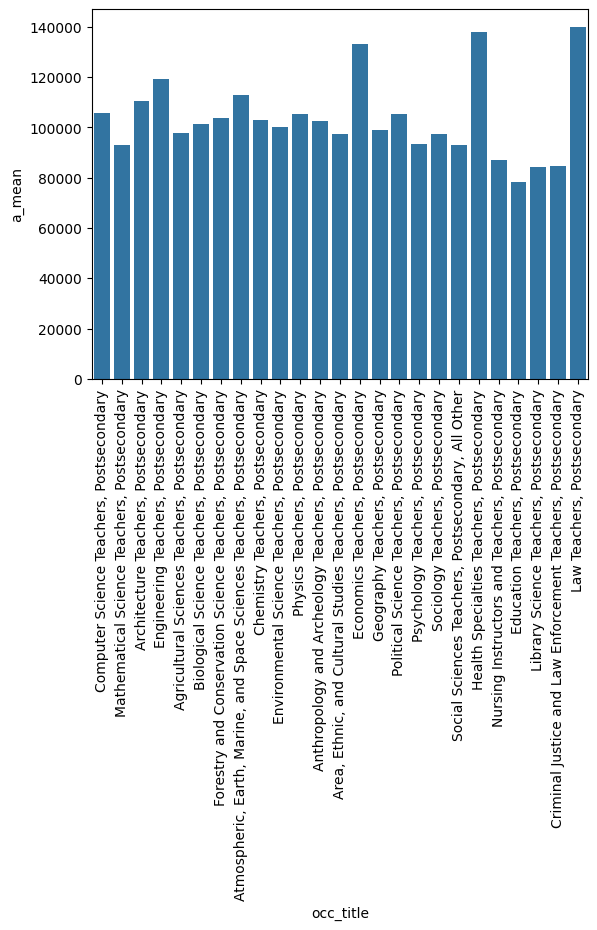

In [62]:
fig, ax = plt.subplots()
_ = sns.barplot(data=temp_edu_detailed.iloc[:25], x='occ_title', y='a_mean')
_ = plt.xticks(rotation=90)
plt.show()

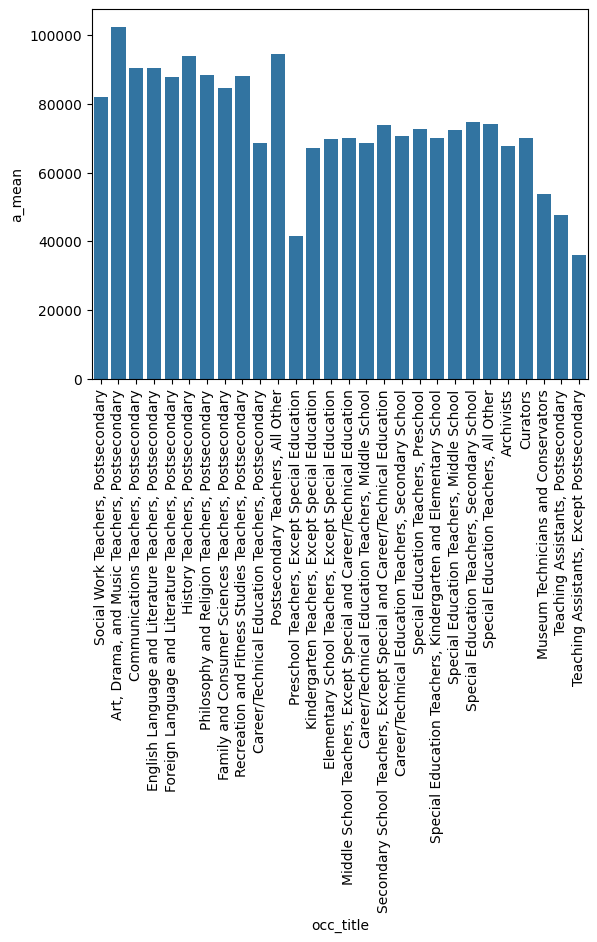

In [63]:
fig, ax = plt.subplots()
_ = sns.barplot(data=temp_edu_detailed.iloc[25:], x='occ_title', y='a_mean')
_ = plt.xticks(rotation=90)
plt.show()

We can see that Postsecondary teacher consistently outperform other categories.

Preschool teachers and Teaching Assistants trail at the bottom of the group.

## Analyzing O*NET `ete`

Our goal now is to join the BLS `nat_data` dataset with the O*NET `ete` dataset.

We'll need to join the other O*NET datasets along the way so as to decode the `ete` dataset and its symbols.

In [64]:
ete.head()

,onetsoc_code,element_id,scale_id,category,data_value,n,standard_error,lower_ci_bound,upper_ci_bound,recommend_suppress,date_updated,domain_source
id,,,,,,,,,,,,
1,11-1011.00,2.D.1,RL,1.0,0.00,28.0,0.0000,NaN,NaN,N,2023-08-01,Incumbent
2,11-1011.00,2.D.1,RL,2.0,4.46,28.0,4.1428,0.6307,25.5524,N,2023-08-01,Incumbent
3,11-1011.00,2.D.1,RL,3.0,0.00,28.0,0.0000,NaN,NaN,N,2023-08-01,Incumbent
4,11-1011.00,2.D.1,RL,4.0,0.00,28.0,0.0000,NaN,NaN,N,2023-08-01,Incumbent
5,11-1011.00,2.D.1,RL,5.0,5.15,28.0,5.2236,0.6000,32.7756,N,2023-08-01,Incumbent


In [65]:
ete.nunique()

onetsoc_code            878
element_id                6
scale_id                  5
category                 12
data_value             4726
n                        68
standard_error        15685
lower_ci_bound        14736
upper_ci_bound        16288
recommend_suppress        2
date_updated             22
domain_source             2
dtype: int64

### Dropping Unnecessary Data from `ete`

Let's remove the rows that the database states are low precision, and therefore low quality.

In [66]:
ete.shape

(37125, 12)

In [67]:
ete[(ete['recommend_suppress'] == 'Y')].shape

(866, 12)

In [68]:
ete = ete[(ete['recommend_suppress'] != 'Y')]

In [69]:
ete.shape

(36259, 12)

Let's eliminate unnecessary columns. (We no longer need to track the `recommend_suppress` column.)

In [70]:
ete = ete.drop(columns=['date_updated', 'domain_source', 'recommend_suppress'])

In [71]:
ete.shape

(36259, 9)

### Analyzing the Use Case of the New Values in `onetsoc_code`

The `onetsoc_code` is, I believe, the column to which we would like to join the `occ_code` in the BLS dataset.

However, the `onetsoc_code` has a decimal point and two digits after it.

Let's analyze.

In [72]:
# For use with regex cases
digits_1_9 = tuple(str(i) for i in range(1, 10))

In [73]:
ete[ete['onetsoc_code'].str.endswith(digits_1_9)]

,onetsoc_code,element_id,scale_id,category,data_value,n,standard_error,lower_ci_bound,upper_ci_bound
id,,,,,,,,,
44,11-1011.03,2.D.1,RL,1.0,0.00,27.0,NaN,NaN,NaN
45,11-1011.03,2.D.1,RL,2.0,0.00,27.0,NaN,NaN,NaN
46,11-1011.03,2.D.1,RL,3.0,0.00,27.0,NaN,NaN,NaN
47,11-1011.03,2.D.1,RL,4.0,0.00,27.0,NaN,NaN,NaN
48,11-1011.03,2.D.1,RL,5.0,0.00,27.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
36785,53-7062.04,3.A.3,OJ,5.0,8.66,20.0,5.0550,2.4262,26.5368
36786,53-7062.04,3.A.3,OJ,6.0,4.45,20.0,4.2155,0.5814,27.0576
36787,53-7062.04,3.A.3,OJ,7.0,0.00,20.0,0.0000,NaN,NaN


In [74]:
ete[ete['onetsoc_code'].str.startswith('11-1011') == True]

,onetsoc_code,element_id,scale_id,category,data_value,n,standard_error,lower_ci_bound,upper_ci_bound
id,,,,,,,,,
1,11-1011.00,2.D.1,RL,1.0,0.00,28.0,0.0000,NaN,NaN
2,11-1011.00,2.D.1,RL,2.0,4.46,28.0,4.1428,0.6307,25.5524
3,11-1011.00,2.D.1,RL,3.0,0.00,28.0,0.0000,NaN,NaN
4,11-1011.00,2.D.1,RL,4.0,0.00,28.0,0.0000,NaN,NaN
5,11-1011.00,2.D.1,RL,5.0,5.15,28.0,5.2236,0.6000,32.7756
...,...,...,...,...,...,...,...,...,...
82,11-1011.03,3.A.3,OJ,6.0,7.41,27.0,NaN,NaN,NaN
83,11-1011.03,3.A.3,OJ,7.0,0.00,27.0,NaN,NaN,NaN
84,11-1011.03,3.A.3,OJ,8.0,3.70,27.0,NaN,NaN,NaN


In [75]:
with pd.option_context('display.max_rows', None):
    print(ete[ete['onetsoc_code'].str.startswith('11-1011') == True][['onetsoc_code', 'scale_id']])

   onetsoc_code scale_id
id                      
1    11-1011.00       RL
2    11-1011.00       RL
3    11-1011.00       RL
4    11-1011.00       RL
5    11-1011.00       RL
6    11-1011.00       RL
7    11-1011.00       RL
8    11-1011.00       RL
9    11-1011.00       RL
10   11-1011.00       RL
11   11-1011.00       RL
12   11-1011.00       RL
13   11-1011.00       IM
14   11-1011.00       RW
15   11-1011.00       RW
16   11-1011.00       RW
17   11-1011.00       RW
18   11-1011.00       RW
19   11-1011.00       RW
20   11-1011.00       RW
21   11-1011.00       RW
22   11-1011.00       RW
23   11-1011.00       RW
24   11-1011.00       RW
25   11-1011.00       PT
26   11-1011.00       PT
27   11-1011.00       PT
28   11-1011.00       PT
29   11-1011.00       PT
30   11-1011.00       PT
31   11-1011.00       PT
32   11-1011.00       PT
34   11-1011.00       OJ
35   11-1011.00       OJ
36   11-1011.00       OJ
37   11-1011.00       OJ
38   11-1011.00       OJ
39   11-1011.00       OJ


After poking around on the dictionary and perusing results such as those above, I learned a few things.

The `.0X` value at the end is a repetition of the same job. I was not yet able to discover how a `.00` and `.01` suffix might indicate a conceptual change.

#### BLS Commentary on Joining with SOC Codes

I found a webpage from BLS that discusses the complexity of joining O*NET and BLS datasets.

[BLS and O*NET Webpage](https://github.com/blue-santa/comparing-training-req-to-salary-exp/blob/main/raw-data/bls-onet-joining-info-snapshot/Mapping%20Employment%20Projections%20and%20O_NET%20data_%20a%20methodological%20overview%20_%20Monthly%20Labor%20Review%20_%20U.S.%20Bureau%20of%20Labor%20Statistics.pdf)

Note the following:

    For a set of occupations, O*NET collects data both at the six-digit SOC level and at the more detailed eight-digit level. For example, O*NET collects data on occupations O*NET-SOC 11-1011.00, chief executives, and O*NET-SOC 11-1011.03, chief sustainability officers. The former occupation is at the six-digit level of detail and maps exactly to SOC 11-1011, chief executives. Chief sustainability officers, on the other hand, are a more detailed subset of the occupation and have no corresponding SOC code. Because a one-to-one match at the correct level of detail already exists, the extra eight-digit O*NET occupation should be thrown out.

    The general mapping procedure for this step involves matching the six-digit O*NET-SOC occupations to the corresponding EP/OEWS occupations and then discarding the more detailed eight-digit O*NET-SOC occupations

Essentially, anything above `.00` will be thrown out in this data exploration.

There is useful information in the additional rows, but reaching that usefulness may be beyond the scope of my limited project.

### Dropping O*NET Increased Specificity Data

With the extra rows of increased specificity removed, we now simplify the `onetsoc_code` column so that it will match the BLS data.

In [76]:
ete = ete[ete['onetsoc_code'].str.endswith('00') == True]

In [77]:
ete['onetsoc_code'] = ete['onetsoc_code'].str[:7]

In [78]:
ete['onetsoc_code'].head()

id
1    11-1011
2    11-1011
3    11-1011
4    11-1011
5    11-1011
Name: onetsoc_code, dtype: object

### Meaning of `data_value`

After some Google research, I discovered that the `data_value` column contains the percentage of respondents who chose a particular category.

    The data_value represents a percentage (0 to 100). It tells you the percentage of job incumbents who selected a particular category for that occupation.
    
    Example: If the data_value for a specific ETE element is 45.5, it means 45.5% of surveyed workers in that occupation chose that specific level of training or education.

## Joining the Datasets

From here, the best thing to do is likely to just create a unified dataframe that contains a column for our target data.

Once we pull everything inward into this master dataframe, we can drop unnecessary content and narrow our focus.

For the BLS `nat_data` dataset, we'll keep `occ_codes`, `o_group`, `a_mean`, and `h_mean`.

We'll join on the `occ_codes`.

For all of the secondary O*NET datasets, we'll pull in the values that are necessary to indicate in plain English what we are supposed to understand about any particular symbol.

### Comparing Joinable Columns

Let's see how these codes match across the two datasets.

We'll create an intermediary dataframe to track how the columns in each match. This will come in handy when we go to merge.

In [79]:
onet_codes = pd.Series(ete['onetsoc_code'].unique())

In [80]:
bls_codes = pd.Series(nat_data['occ_code'].unique())

In [81]:
lowest_present = np.isin(onet_codes, bls_codes)

In [82]:
match_df = pd.DataFrame({'onet_code': onet_codes, 'lowest_present': lowest_present})

In [83]:
match_df

,onet_code,lowest_present
0,11-1011,False
1,11-1021,False
2,11-2011,False
3,11-2021,True
4,11-2022,True
...,...,...
728,53-7071,True
729,53-7072,True
730,53-7073,True
731,53-7081,False


In [84]:
nat_data[nat_data['occ_code'].str.startswith('11-10') == True]

,occ_code,occ_title,o_group,tot_emp,emp_prse,h_mean,a_mean,mean_prse,h_pct10,h_pct25,h_median,h_pct75,h_pct90,a_pct10,a_pct25,a_median,a_pct75,a_pct90,annual,hourly
id,,,,,,,,,,,,,,,,,,,,
3,11-1000,Top Executives,minor,3822780,0.3,67.24,139860.0,0.4,22.84,33.08,50.48,81.01,115.0,47510.0,68800.0,104990.0,168490.0,239200.0,None,None
4,11-1010,Chief Executives,broad,211850,1.2,126.41,262930.0,0.9,35.44,60.61,99.24,115.00,115.0,73710.0,126080.0,206420.0,239200.0,239200.0,None,None
5,11-1020,General and Operations Managers,broad,3584420,0.4,64.00,133120.0,0.4,22.80,32.29,49.50,78.91,115.0,47420.0,67160.0,102950.0,164130.0,239200.0,None,None
6,11-1030,Legislators,broad,26510,3.9,NaN,67390.0,1.6,NaN,NaN,NaN,NaN,NaN,20380.0,29120.0,44810.0,80350.0,137820.0,True,None


### Creating Match Values

Some of the O*NET codes, at six-digit specificity, are not present in the same form in the BLS dataset.

For example, the O*NET dataset has `11-1011`, `11-1012`, etc., but BLS only has `11-1010`.

The BLS values shows that BLS contains the `broad` category, but not rows for the `detailed` data.

I searched around in the datasets in previous states in the database. At least at a glance, it would appear that the original BLS data was always like this.

When O*NET `detailed` data does not have a matching `detailed` row in BLS, we'll simply have to insert the `broad` BLS value.

This pattern will continue through the `minor` and `major` levels, as needed. 

In [85]:
# Add a column to track which BLS code we will match to each ONET code
match_df['bls_code_to_match'] = str

In [86]:
# If a match is currently found, set the match BLS code to the current ONET code
match_df.loc[match_df['lowest_present'] == True, 'bls_code_to_match'] = match_df['onet_code']

In [87]:
match_df

,onet_code,lowest_present,bls_code_to_match
0,11-1011,False,<class 'str'>
1,11-1021,False,<class 'str'>
2,11-2011,False,<class 'str'>
3,11-2021,True,11-2021
4,11-2022,True,11-2022
...,...,...,...
728,53-7071,True,53-7071
729,53-7072,True,53-7072
730,53-7073,True,53-7073
731,53-7081,False,<class 'str'>


Let's limit the search to see if fewer code digits have matches across the two datasets.

In [88]:
# Check whether there is a matching BLS code if we limit the ONET code to five digits
match_df['broad_present'] = np.isin(match_df['onet_code'].str[:6], bls_codes.str[:6])

In [89]:
# When the first test was false but the broad test was true, insert the broad code value
match_df.loc[((match_df['lowest_present'] == False) & (match_df['broad_present'] == True)), 'bls_code_to_match'] = match_df['onet_code'].str[:6] + '0'

In [90]:
# Visually inspect
match_df[(match_df['lowest_present'] == False) & (match_df['broad_present'] == True)]

,onet_code,lowest_present,bls_code_to_match,broad_present
0,11-1011,False,11-1010,True
1,11-1021,False,11-1020,True
2,11-2011,False,11-2010,True
8,11-3021,False,11-3020,True
9,11-3031,False,11-3030,True
...,...,...,...,...
720,53-7031,False,53-7030,True
721,53-7041,False,53-7040,True
722,53-7051,False,53-7050,True
731,53-7081,False,53-7080,True


In [91]:
# Visually inspect
match_df[match_df['broad_present'] == False]

,onet_code,lowest_present,bls_code_to_match,broad_present
398,39-7011,False,<class 'str'>,False
399,39-7012,False,<class 'str'>,False
424,43-1011,False,<class 'str'>,False
473,45-1011,False,<class 'str'>,False
480,45-3031,False,<class 'str'>,False
485,47-1011,False,<class 'str'>,False
542,49-1011,False,<class 'str'>,False
591,51-1011,False,<class 'str'>,False


We can see that by focusing only on the first five digits, we can handle most of the values.

However, there are still a few stubborn values that do not seem to appear in the database in their `broad` form.

In [92]:
# Test if there is a minor BLS code available
match_df['minor_present'] = np.isin(match_df['onet_code'].str[:5], bls_codes.str[:5])

In [93]:
# For the new minor matches, set the code value
match_df.loc[(match_df['broad_present'] == False) & (match_df['minor_present'] == True), 'bls_code_to_match'] = match_df['onet_code'].str[:5] + '00'

In [94]:
# Visually inspect
match_df[(match_df['lowest_present'] == False) & (match_df['broad_present'] == False) & (match_df['minor_present'] == True)]

,onet_code,lowest_present,bls_code_to_match,broad_present,minor_present
398,39-7011,False,39-7000,False,True
399,39-7012,False,39-7000,False,True


In [95]:
# Visually inspect
match_df[match_df['minor_present'] == False]

,onet_code,lowest_present,bls_code_to_match,broad_present,minor_present
424,43-1011,False,<class 'str'>,False,False
473,45-1011,False,<class 'str'>,False,False
480,45-3031,False,<class 'str'>,False,False
485,47-1011,False,<class 'str'>,False,False
542,49-1011,False,<class 'str'>,False,False
591,51-1011,False,<class 'str'>,False,False


We knocked a few more off. Let's see if the BLS codes even have the major categories listed here.

In [96]:
# A new column to test the major values
match_df['major_present'] = np.isin(match_df['onet_code'].str[:2], bls_codes.str[:2])

In [97]:
# For the new major matches, set the code value
match_df.loc[(match_df['minor_present'] == False) & (match_df['major_present'] == True), 'bls_code_to_match'] = match_df['onet_code'].str[:2] + '-0000'

In [98]:
# Visually inspect
match_df[(match_df['minor_present'] == False) & (match_df['major_present'] == True)]

,onet_code,lowest_present,bls_code_to_match,broad_present,minor_present,major_present
424,43-1011,False,43-0000,False,False,True
473,45-1011,False,45-0000,False,False,True
480,45-3031,False,45-0000,False,False,True
485,47-1011,False,47-0000,False,False,True
542,49-1011,False,49-0000,False,False,True
591,51-1011,False,51-0000,False,False,True


In [99]:
# Visually inspect
match_df[match_df['major_present'] == False]

,onet_code,lowest_present,bls_code_to_match,broad_present,minor_present,major_present


### Observation on How We'll Use `o_group`

There's an important note to make here about how we've generatlized some of the O*NET data.

We're keeping the O*NET `onetsoc_code` column, but the BLS dataset did not always have perfect matches. In those cases, we have set ourselves up to take more general financial information to use as a substitute.

`specific O*NET career not found in BLS` -> `broad financial income from BLS substituted`

If we want to run a visualization or analysis where being specific is paramount, we can simply run visualizations on just those rows where the `onetsoc_code` perfectly matches the BLS `occ_code`.

### Validating Logic

Now, we need to visually inspect the previous rows to make sure the logic did not overwrite our work.

In [100]:
match_df.head(10)

,onet_code,lowest_present,bls_code_to_match,broad_present,minor_present,major_present
0,11-1011,False,11-1010,True,True,True
1,11-1021,False,11-1020,True,True,True
2,11-2011,False,11-2010,True,True,True
3,11-2021,True,11-2021,True,True,True
4,11-2022,True,11-2022,True,True,True
5,11-2033,True,11-2033,True,True,True
6,11-3012,True,11-3012,True,True,True
7,11-3013,True,11-3013,True,True,True
8,11-3021,False,11-3020,True,True,True
9,11-3031,False,11-3030,True,True,True


We can see instances above where the most specific columns transferred correctly.

The same goes for broad columns.

Let's take a look at `minor` columns.

In [101]:
match_df[(match_df['broad_present'] == False) & (match_df['minor_present'] == True)]

,onet_code,lowest_present,bls_code_to_match,broad_present,minor_present,major_present
398,39-7011,False,39-7000,False,True,True
399,39-7012,False,39-7000,False,True,True


In [102]:
match_df[(match_df['minor_present'] == False) & (match_df['major_present'] == True)]

,onet_code,lowest_present,bls_code_to_match,broad_present,minor_present,major_present
424,43-1011,False,43-0000,False,False,True
473,45-1011,False,45-0000,False,False,True
480,45-3031,False,45-0000,False,False,True
485,47-1011,False,47-0000,False,False,True
542,49-1011,False,49-0000,False,False,True
591,51-1011,False,51-0000,False,False,True


#### Edge Case

Our final test is to ensure that all of the new match codes in `bls_code_to_match` are in the BLS codes.

In [103]:
print(np.sum(~match_df['bls_code_to_match'].isin(bls_codes)))

2


In [104]:
match_df[~match_df['bls_code_to_match'].isin(bls_codes)]

,onet_code,lowest_present,bls_code_to_match,broad_present,minor_present,major_present
691,53-1042,False,53-1040,True,True,True
692,53-1043,False,53-1040,True,True,True


Interesting. There are two codes in the O*NET dataset that match up to five digits, but there's no actual BLS `broad` category that matches. 

Let's see what the BLS codes do have that starts with the same digits.

In [105]:
bls_codes[bls_codes.str.startswith('53-104') == True]

1009    53-1041
1010    53-1047
dtype: object

Indeed, by this measure, BLS seems to not have a `broad` row. However, it does have two `detailed` rows.

In [106]:
print(len(nat_data[nat_data['occ_code'].str.startswith('53') == True]))

62


In [107]:
print(len(nat_data[nat_data['occ_code'].str.startswith('53-1') == True]))

2


Right there, we have it. Let's look at those rows.

In [108]:
nat_data[nat_data['occ_code'].str.startswith('53-1') == True]

,occ_code,occ_title,o_group,tot_emp,emp_prse,h_mean,a_mean,mean_prse,h_pct10,h_pct25,h_median,h_pct75,h_pct90,a_pct10,a_pct25,a_median,a_pct75,a_pct90,annual,hourly
id,,,,,,,,,,,,,,,,,,,,
1010,53-1041,Aircraft Cargo Handling Supervisors,detailed,10160,4.4,31.82,66190.0,2.2,18.27,23.57,30.74,38.27,46.30,38010.0,49020.0,63940.0,79600.0,96300.0,None,None
1011,53-1047,First-Line Supervisors of Transportation and M...,detailed,605510,0.4,31.57,65670.0,0.3,19.85,23.44,29.76,37.27,45.59,41290.0,48750.0,61890.0,77520.0,94830.0,None,None


These two rows are not in the O*NET dataset.

Let's look at the O*NET rows that do not have matching codes in the BLS dataset.

The titles of these jobs are found in the Occupation Data dataset.

In [109]:
occupation_data[occupation_data['onetsoc_code'].str.startswith('53-1') == True]

,onetsoc_code,title,description
id,,,
941,53-1041.00,Aircraft Cargo Handling Supervisors,Supervise and coordinate the activities of gro...
942,53-1042.00,"First-Line Supervisors of Helpers, Laborers, a...",Directly supervise and coordinate the activiti...
943,53-1042.01,Recycling Coordinators,Supervise curbside and drop-off recycling prog...
944,53-1043.00,First-Line Supervisors of Material-Moving Mach...,Directly supervise and coordinate activities o...
945,53-1044.00,First-Line Supervisors of Passenger Attendants,Supervise and coordinate activities of passeng...
946,53-1049.00,First-Line Supervisors of Transportation Worke...,All first-line supervisors of transportation w...


The two present in the O*NET `ete` dataset are `53-1042` and `53-1043`, which are Recycling Coordinators and First-Line Supervisors of Material-Moving Machinery.

Let's see if those titles show up in the BLS dataset.

In [110]:
nat_data[nat_data['occ_title'].str.contains('ecycling', regex=False) == True]

,occ_code,occ_title,o_group,tot_emp,emp_prse,h_mean,a_mean,mean_prse,h_pct10,h_pct25,h_median,h_pct75,h_pct90,a_pct10,a_pct25,a_median,a_pct75,a_pct90,annual,hourly
id,,,,,,,,,,,,,,,,,,,,


In [111]:
nat_data[nat_data['occ_title'].str.contains('Material-Moving', regex=False) == True]

,occ_code,occ_title,o_group,tot_emp,emp_prse,h_mean,a_mean,mean_prse,h_pct10,h_pct25,h_median,h_pct75,h_pct90,a_pct10,a_pct25,a_median,a_pct75,a_pct90,annual,hourly
id,,,,,,,,,,,,,,,,,,,,


#### Dropping Unnecessary `ete` Rows

Let's go ahead and drop those rows from `ete` and not worry about them.

In [112]:
ete.shape

(30141, 9)

In [113]:
ete = ete[(ete['onetsoc_code'] != '53-1042') & (ete['onetsoc_code'] != '53-1043')]

In [114]:
ete.shape

(30061, 9)

### Transferring BLS Codes to O*NET

Before transferring the match codes to O*NET, we need to limit the `match_df` to only those columns that are necessary.

In [115]:
match_df = match_df.drop(columns=['lowest_present', 'broad_present', 'minor_present', 'major_present'])

In [116]:
match_df.head()

,onet_code,bls_code_to_match
0,11-1011,11-1010
1,11-1021,11-1020
2,11-2011,11-2010
3,11-2021,11-2021
4,11-2022,11-2022


Now we can go ahead and do a left join.

Let's create a new dataframe.

In [117]:
full_df = pd.merge(ete, match_df, left_on='onetsoc_code', right_on='onet_code')

In [118]:
full_df = full_df.drop(columns=['onet_code'])

In [119]:
full_df.head()

,onetsoc_code,element_id,scale_id,category,data_value,n,standard_error,lower_ci_bound,upper_ci_bound,bls_code_to_match
0,11-1011,2.D.1,RL,1.0,0.00,28.0,0.0000,NaN,NaN,11-1010
1,11-1011,2.D.1,RL,2.0,4.46,28.0,4.1428,0.6307,25.5524,11-1010
2,11-1011,2.D.1,RL,3.0,0.00,28.0,0.0000,NaN,NaN,11-1010
3,11-1011,2.D.1,RL,4.0,0.00,28.0,0.0000,NaN,NaN,11-1010
4,11-1011,2.D.1,RL,5.0,5.15,28.0,5.2236,0.6000,32.7756,11-1010


### Observations on Transferring Other O*NET Datasets into Full

In [120]:
ete_categories.head(2)

,element_id,scale_id,category,category_description
id,,,,
1,2.D.1,RL,1.0,Less than a High School Diploma
2,2.D.1,RL,2.0,High School Diploma - or the equivalent (for e...


In [121]:
ete_categories.shape

(41, 4)

Both the full and the categories datasets may need to have the associated columns combined into a single before we can properly join.

In [122]:
occupation_data.head(2)

,onetsoc_code,title,description
id,,,
1,11-1011.00,Chief Executives,Determine and formulate policies and provide o...
2,11-1011.03,Chief Sustainability Officers,"Communicate and coordinate with management, sh..."


In [123]:
occupation_data.shape

(1016, 3)

This one should be easy. We will pull in the title from Occupation Data and leave the rest.

In [124]:
content_model_reference.head(3)

,element_id,element_name,description
id,,,
1,1,Worker Characteristics,Worker Characteristics
2,1.A,Abilities,Enduring attributes of the individual that inf...
3,1.A.1,Cognitive Abilities,Abilities that influence the acquisition and a...


In [125]:
content_model_reference.shape

(630, 3)

This one may be a little bit tricky. We may want to keep all the heirarchal elements for each row.

In other words, we might want a column that looks like:

```
Worker Characteristics : Abilities : Cognitive Abilities
```

We would need to use `.` as a delimiter.

This would help clarify the values that the `ete` dataset marks for value.

In [126]:
scales_reference.head(5)

,scale_id,scale_name,minimum,maximum
id,,,,
1,AO,Automation,1.0,5.0
2,CF,Frequency,1.0,5.0
3,CN,Amount of Contact,1.0,5.0
4,CT,Context,1.0,3.0
5,CTP,Context (Categories 1-3),0.0,100.0


In [127]:
scales_reference.shape

(31, 4)

This is another easy one. We'll simply match via `scale_id`.

### `ete_categories`

In [128]:
full_df.head(1)

,onetsoc_code,element_id,scale_id,category,data_value,n,standard_error,lower_ci_bound,upper_ci_bound,bls_code_to_match
0,11-1011,2.D.1,RL,1.0,0.0,28.0,0.0,NaN,NaN,11-1010


In [129]:
ete_categories.head(1)

,element_id,scale_id,category,category_description
id,,,,
1,2.D.1,RL,1.0,Less than a High School Diploma


To combine the two datasets, the first thing we want to do is create a new column that concatenates all the columns that are needed to make a match.

We'll do this in both datasets and then join on those columns when we're ready.

In [130]:
full_df['category_compressed'] = full_df['element_id'] + ' ' + full_df['scale_id'] + ' ' + full_df['category'].astype(str)

In [131]:
ete_categories['category_compressed'] = ete_categories['element_id'] + ' ' + ete_categories['scale_id'] + ' ' + ete_categories['category'].astype(str)

#### Checking for Cross-Dataset Consistency

Let's test and make sure that each of the categories in our `full_df` dataset can be found in the `ete_categories` dataset.

In [132]:
full_df['ete_category_is_in_category'] = np.isin(full_df['category_compressed'], ete_categories['category_compressed'])

In [133]:
full_df[(full_df['ete_category_is_in_category'] == False)].head()

,onetsoc_code,element_id,scale_id,category,data_value,n,standard_error,lower_ci_bound,upper_ci_bound,bls_code_to_match,category_compressed,ete_category_is_in_category
12,11-1011,2.D.4.a,IM,NaN,3.01,28.0,0.2773,2.4454,3.5834,11-1010,2.D.4.a IM nan,False
40,11-1011,3.A.4.a,IM,NaN,2.20,27.0,0.3437,1.4926,2.9055,11-1010,3.A.4.a IM nan,False
53,11-1021,2.D.4.a,IM,NaN,1.88,28.0,0.2508,1.3704,2.3996,11-1020,2.D.4.a IM nan,False
83,11-1021,3.A.4.a,IM,NaN,2.33,28.0,0.3483,1.6139,3.0434,11-1020,3.A.4.a IM nan,False
96,11-2011,2.D.4.a,IM,NaN,1.98,23.0,0.2188,1.5213,2.4288,11-2010,2.D.4.a IM nan,False


We have some that have a value in `category`, `NaN`, that is causing issues. Let's investigate rows with this value.

#### Investigating the Non-Compatible Rows

We see that some of these non-compatible rows have a `scale_id` value of `IM`.

Let's check and see if any of the target rows do not have a `scale_id` value of `IM`.

In [134]:
full_df[(full_df['ete_category_is_in_category'] == False) & (full_df['scale_id'] != 'IM')]

,onetsoc_code,element_id,scale_id,category,data_value,n,standard_error,lower_ci_bound,upper_ci_bound,bls_code_to_match,category_compressed,ete_category_is_in_category


Nothing found.

Let's check and see what the `scale_id` value means.

In [135]:
scales_reference[scales_reference['scale_id'] == 'IM']

,scale_id,scale_name,minimum,maximum
id,,,,
15,IM,Importance,1.0,5.0


These values are about `Importance`. From what we can understand, respondents to the survey would rate their values on the associated category in terms of importance on a scale of `1` to `5`.

Apparently, when it comes to missing `category` values, we're just dealing with the issue of respondent-importance rating.

#### Investigating the Overall `scale_id` Values

To better understand what is happening in these non-compatible rows, let's look through the meaning of the associated columns and their values.

We'll perform a check to see which types of `scale_id` values are actually in both datasets.

In [136]:
full_df['scale_id'].unique()

array(['RL', 'IM', 'RW', 'PT', 'OJ'], dtype=object)

In [137]:
ete_categories['scale_id'].unique()

array(['RL', 'RW', 'PT', 'OJ'], dtype=object)

The only difference is that the `full_df` contains `IM`, which is the one that has missing `category` values.

Let's see what these `scale_id` values represent in the `scales_reference` dataset.

In [138]:
scales_reference[scales_reference['scale_id'].isin(['RW', 'PT', 'OJ', 'RL', 'IM']) == True]

,scale_id,scale_name,minimum,maximum
id,,,,
15,IM,Importance,1.0,5.0
20,OJ,On-The-Job Training (Categories 1-9),0.0,100.0
21,PT,On-Site Or In-Plant Training (Categories 1-9),0.0,100.0
24,RL,Required Level Of Education (Categories 1-12),0.0,100.0
26,RW,Related Work Experience (Categories 1-11),0.0,100.0


We've already seen `IM`.

The other four values, `OJ`, `PT`, `RL`, `RW` refer to experience, training, and education. 

For each `scale_id` value, there are anywhere from `9` to `11` total categories.

The `minimum` and `maximum` values reference to the percentage of respondents who selected that `scale_id`-`category_id` combination. In other words, anywhere from `0%` to `100%` of respondents could have selected that category.

For example, regarding `RL` (our target metric), the survey question would be along the lines of:

    "What is the minimum level of education required to perform this job?"

The respondents would then have the options presented to them below:

In [139]:
ete_categories[ete_categories['scale_id'] == 'RL']

,element_id,scale_id,category,category_description,category_compressed
id,,,,,
1,2.D.1,RL,1.0,Less than a High School Diploma,2.D.1 RL 1.0
2,2.D.1,RL,2.0,High School Diploma - or the equivalent (for e...,2.D.1 RL 2.0
3,2.D.1,RL,3.0,Post-Secondary Certificate - awarded for train...,2.D.1 RL 3.0
4,2.D.1,RL,4.0,Some College Courses,2.D.1 RL 4.0
5,2.D.1,RL,5.0,Associate's Degree (or other 2-year degree),2.D.1 RL 5.0
6,2.D.1,RL,6.0,Bachelor's Degree,2.D.1 RL 6.0
7,2.D.1,RL,7.0,Post-Baccalaureate Certificate - awarded for c...,2.D.1 RL 7.0
8,2.D.1,RL,8.0,Master's Degree,2.D.1 RL 8.0
9,2.D.1,RL,9.0,Post-Master's Certificate - awarded for comple...,2.D.1 RL 9.0


Each category value respresents a different value of experience or training required for someone performing the job. 

There are twelve total options, each representing the level of training that a respondent feels is necessary to do their job.

#### Commentary Regarding `RL`

The content that is related to paid education level (which is typically paid in the U.S.) is relevant.

**We want to know how much a person has to invest into a entering any given field in terms of time and money, and then observe how much they make in that field.**

We'll want to compare low values of `RL` categories and their matching salaries to high values of `RL` categories and their matching values.

Because this is our target data, we'll want to keep all the rows that have the `scale_id` option of `RL`.

(We note here that the values are discrete, which is not ideal since we want to do linear regression.)

#### Commentary on the `scale_id` Values: `OJ`, `PT`, and `RW`

The other four values, `OJ`, `PT`, and `RW`, all related to experience and training that would be performed on-the-job. Because this type of career growth is paid, as opposed to requiring an investment from the employee, we do not wish to include these rows in our analysis. 

We will drop them when the time comes.

#### Analyzing the `IM`-associated `element_id` Values

Before we drop any rows, let's look at the meaning of the specific `element_id` values associated with `IM` (and thereby associated with the missing `category` values).

In [140]:
full_df[full_df['scale_id'] == 'IM']['element_id'].unique()

array(['2.D.4.a', '3.A.4.a'], dtype=object)

In [141]:
elements_to_observe = full_df[full_df['scale_id'] == 'IM']['element_id'].unique()

In [142]:
content_model_reference[content_model_reference['element_id'].isin(elements_to_observe) == True]

,element_id,element_name,description
id,,,
292,2.D.4.a,Job-Related Professional Certification,Possession of an occupational or industry cert...
299,3.A.4.a,Job-related Apprenticeship,Completion of a job-related apprenticeship to ...


If I understand correctly, what we see here is that, in regards to the `IM` importance question, the survey is asking how important it is that a worker in this industry have a certification or apprenticeship.

A an Importance question might look something like:

    "How important is it that an employee in this field have a job-related professional certification?"

As seen earlier, the respondent indicates the importance of this certification or apprenticeship on a scale of `1` to `5`.

##### Importance is Not Important -- At Least, Concerning Certification

The `RL` category already had options that included certifications, alongside questions about post-secondary education.

On the one hand, it is possible that we could use the `IM` rows that are related to professional certification to analyze each career field and its associated certification.

However, our time is not unlimited and we need to restrict the scope of our analysis.

For this project, we will go ahead and drop the `IM` rows.

#### A Preview Before Dropping

Let's look at one specific occupation and see what our ultimate analysis will entail.

In [143]:
occupation_data[occupation_data['onetsoc_code'].str.startswith('11-1011') == True]

,onetsoc_code,title,description
id,,,
1,11-1011.00,Chief Executives,Determine and formulate policies and provide o...
2,11-1011.03,Chief Sustainability Officers,"Communicate and coordinate with management, sh..."


Take `Chief Executives` for our observation.

In [144]:
full_df[(full_df['scale_id'] == 'RL') & (full_df['onetsoc_code'] == '11-1011')]

,onetsoc_code,element_id,scale_id,category,data_value,n,standard_error,lower_ci_bound,upper_ci_bound,bls_code_to_match,category_compressed,ete_category_is_in_category
0,11-1011,2.D.1,RL,1.0,0.00,28.0,0.0000,NaN,NaN,11-1010,2.D.1 RL 1.0,True
1,11-1011,2.D.1,RL,2.0,4.46,28.0,4.1428,0.6307,25.5524,11-1010,2.D.1 RL 2.0,True
2,11-1011,2.D.1,RL,3.0,0.00,28.0,0.0000,NaN,NaN,11-1010,2.D.1 RL 3.0,True
3,11-1011,2.D.1,RL,4.0,0.00,28.0,0.0000,NaN,NaN,11-1010,2.D.1 RL 4.0,True
4,11-1011,2.D.1,RL,5.0,5.15,28.0,5.2236,0.6000,32.7756,11-1010,2.D.1 RL 5.0,True
5,11-1011,2.D.1,RL,6.0,32.29,28.0,12.7266,12.6247,61.1586,11-1010,2.D.1 RL 6.0,True
6,11-1011,2.D.1,RL,7.0,0.00,28.0,0.0000,NaN,NaN,11-1010,2.D.1 RL 7.0,True
7,11-1011,2.D.1,RL,8.0,45.91,28.0,16.6480,17.6593,77.0570,11-1010,2.D.1 RL 8.0,True
8,11-1011,2.D.1,RL,9.0,3.94,28.0,4.0634,0.4511,27.0734,11-1010,2.D.1 RL 9.0,True
9,11-1011,2.D.1,RL,10.0,0.55,28.0,0.5831,0.0637,4.6529,11-1010,2.D.1 RL 10.0,True


As we can see here, respondents tended to choose options such as category `2.0`, `6.0`, and `8.0`.

We can decode those options here.

In [145]:
ete_categories[(ete_categories['scale_id'] == 'RL') & (ete_categories['category'].isin([2.0, 6.0, 8.0]))]

,element_id,scale_id,category,category_description,category_compressed
id,,,,,
2,2.D.1,RL,2.0,High School Diploma - or the equivalent (for e...,2.D.1 RL 2.0
6,2.D.1,RL,6.0,Bachelor's Degree,2.D.1 RL 6.0
8,2.D.1,RL,8.0,Master's Degree,2.D.1 RL 8.0


Therefore most of the respondents who were asked about how much education and training is required to work as a Chief Executive favored having a degree.

#### Dropping Unnecessary Rows and Columns from `full_df`

##### Dropping Rows from `full_df`

It's time to drop all rows that are not about education.

In [146]:
full_df.shape

(30061, 12)

In [147]:
full_df = full_df[full_df['scale_id'] == 'RL']

In [148]:
full_df.shape

(8558, 12)

##### Dropping Unnecessary Columns from `full_df`

Some of these columns now contain only one unique value.

In [149]:
full_df.nunique()

onetsoc_code                    730
element_id                        1
scale_id                          1
category                         12
data_value                     2122
n                                53
standard_error                 2745
lower_ci_bound                 2701
upper_ci_bound                 2779
bls_code_to_match               720
category_compressed              12
ete_category_is_in_category       1
dtype: int64

In [150]:
full_df['element_id'].unique()

array(['2.D.1'], dtype=object)

In [151]:
full_df['scale_id'].unique()

array(['RL'], dtype=object)

In [152]:
content_model_reference[content_model_reference['element_id'] == '2.D.1']

,element_id,element_name,description
id,,,
273,2.D.1,Required Level of Education,The level of education required to perform a job.


In [153]:
scales_reference[scales_reference['scale_id'] == 'RL']

,scale_id,scale_name,minimum,maximum
id,,,,
24,RL,Required Level Of Education (Categories 1-12),0.0,100.0


In [154]:
full_df['ete_category_is_in_category'].unique()

array([ True])

We don't need these three columns.

In [155]:
full_df = full_df.drop(columns=['element_id', 'scale_id', 'ete_category_is_in_category'])

#### Prepping `ete_categories` for the Merge

After the merge between `full_df` and `ete_categories`, we'll have redundant columns: the `category`, and `category_compressed` columns are already in both. We will really only need the `category` column.

To perform the merge, we'll want to rename the `ete_categories_compressed` column beforehand, so it's not duplicated, then drop the unnecessary columns afterward.

In [156]:
ete_categories.columns

Index(['element_id', 'scale_id', 'category', 'category_description',
       'category_compressed'],
      dtype='object')

In [157]:
ete_categories.columns = ['element_id', 'scale_id', 'category', 'category_description',
       'ete_category_compressed']

In [158]:
ete_categories.head(2)

,element_id,scale_id,category,category_description,ete_category_compressed
id,,,,,
1,2.D.1,RL,1.0,Less than a High School Diploma,2.D.1 RL 1.0
2,2.D.1,RL,2.0,High School Diploma - or the equivalent (for e...,2.D.1 RL 2.0


In [159]:
full_df = pd.merge(full_df, ete_categories[['ete_category_compressed', 'category_description']], left_on='category_compressed', right_on='ete_category_compressed')

In [160]:
full_df.head(2)

,onetsoc_code,category,data_value,n,standard_error,lower_ci_bound,upper_ci_bound,bls_code_to_match,category_compressed,ete_category_compressed,category_description
0,11-1011,1.0,0.00,28.0,0.0000,NaN,NaN,11-1010,2.D.1 RL 1.0,2.D.1 RL 1.0,Less than a High School Diploma
1,11-1011,2.0,4.46,28.0,4.1428,0.6307,25.5524,11-1010,2.D.1 RL 2.0,2.D.1 RL 2.0,High School Diploma - or the equivalent (for e...


Now, let's drop the columns that we used just for the merge.

In [161]:
full_df = full_df.drop(columns=['category_compressed', 'ete_category_compressed'])

### `occupation_data`

This df should be significantly easier to merge.

In [162]:
full_df.head(1)

,onetsoc_code,category,data_value,n,standard_error,lower_ci_bound,upper_ci_bound,bls_code_to_match,category_description
0,11-1011,1.0,0.0,28.0,0.0,NaN,NaN,11-1010,Less than a High School Diploma


In [163]:
occupation_data.head(1)

,onetsoc_code,title,description
id,,,
1,11-1011.00,Chief Executives,Determine and formulate policies and provide o...


In [164]:
occupation_data['onetsoc_code_lim'] = occupation_data['onetsoc_code'].str[:7]

In [165]:
occupation_data.head(1)

,onetsoc_code,title,description,onetsoc_code_lim
id,,,,
1,11-1011.00,Chief Executives,Determine and formulate policies and provide o...,11-1011


In [166]:
occupation_data = occupation_data.drop(columns=['description', 'onetsoc_code'])

In [167]:
occupation_data.head(1)

,title,onetsoc_code_lim
id,,
1,Chief Executives,11-1011


In [168]:
occupation_data.columns=['occupation_title', 'onetsoc_code_lim']

In [169]:
full_df = pd.merge(full_df, occupation_data, left_on='onetsoc_code', right_on='onetsoc_code_lim')

### BLS `nat_data` Merge

The time has finally arrived to merge the two datasets together.

In [170]:
full_df = pd.merge(full_df, nat_data[['a_mean', 'h_mean', 'occ_code', 'occ_title', 'o_group']], left_on='bls_code_to_match', right_on='occ_code')

In [171]:
full_df.head(1)

,onetsoc_code,category,data_value,n,standard_error,lower_ci_bound,upper_ci_bound,bls_code_to_match,category_description,occupation_title,onetsoc_code_lim,a_mean,h_mean,occ_code,occ_title,o_group
0,11-1011,1.0,0.0,28.0,0.0,NaN,NaN,11-1010,Less than a High School Diploma,Chief Executives,11-1011,262930.0,126.41,11-1010,Chief Executives,broad


### Remove Excess Columns

The following columns are unlikely to be useful for our analysis.

In [172]:
full_df = full_df.drop(columns=['onetsoc_code_lim', 'n', 'standard_error',
       'lower_ci_bound', 'upper_ci_bound', 'bls_code_to_match'])

We will keep the `occ_code`, so that we have the option to see if the associated BLS financial values are paired `1:1`, or if we had to generalize by going upward through the `o_group` categories (`detailed` to `broad` to `minor` to `major`).

### Reorder the Columns

Reindex the columns to make the order more readable.

In [173]:
full_df.columns

Index(['onetsoc_code', 'category', 'data_value', 'category_description',
       'occupation_title', 'a_mean', 'h_mean', 'occ_code', 'occ_title',
       'o_group'],
      dtype='object')

In [174]:
full_df = full_df.reindex(columns=['onetsoc_code', 'occ_code', 'occupation_title', 'occ_title', 'o_group', 'category', 'category_description', 'data_value', 'a_mean', 'h_mean'])

In [175]:
full_df.head(1)

,onetsoc_code,occ_code,occupation_title,occ_title,o_group,category,category_description,data_value,a_mean,h_mean
0,11-1011,11-1010,Chief Executives,Chief Executives,broad,1.0,Less than a High School Diploma,0.0,262930.0,126.41


In [176]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9324 entries, 0 to 9323
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   onetsoc_code          9324 non-null   object 
 1   occ_code              9324 non-null   object 
 2   occupation_title      9324 non-null   object 
 3   occ_title             9324 non-null   object 
 4   o_group               9324 non-null   object 
 5   category              9324 non-null   float64
 6   category_description  9324 non-null   object 
 7   data_value            9324 non-null   float64
 8   a_mean                9289 non-null   float64
 9   h_mean                8673 non-null   float64
dtypes: float64(4), object(6)
memory usage: 728.6+ KB


# Inserting `full_fd` Into PostgreSQL

In [177]:
# Renew the inspector
inspector = inspect(engine)

In [178]:
new_schema_name = 'stage_01'

In [179]:
# Check if the new schema exists. If not, create it.
# Adapted from a Google search, 'sqlalchemy how to create a schema'
with engine.connect() as conn:
    if not inspect(conn).has_schema(new_schema_name):
        conn.execute(CreateSchema(new_schema_name))
        conn.commit()
    else:
        print(f'{new_schema_name} already exists')

## Inserting the Data

In [180]:
full_df_table_name = 'full_df'

In [181]:
next_table_name = full_df_table_name

In [182]:
# Renew the inspector
inspector = inspect(engine)

next_table_exists = inspector.has_table(next_table_name, schema=new_schema_name)

print(f"{next_table_name} table already exists: {next_table_exists}")

if not next_table_exists: 
    class Base(DeclarativeBase):            
        pass
    
    class User(Base):
    
        print(f"Creating schema.table: {new_schema_name}.{next_table_name}")
        
        # Set initial args
        __tablename__ = next_table_name
        # To place this table in a specific schema:
        __table_args__ = {"schema": new_schema_name} 

        # Add columns
        id: Mapped[int] = mapped_column(BigInteger, primary_key=True)
        onetsoc_code = Column(String)
        occ_code = Column(String)
        occupation_title = Column(String)
        occ_title = Column(String)
        o_group = Column(String)
        category = Column(Float)
        category_description = Column(String)
        data_value = Column(Float) 
        a_mean = Column(Float)
        h_mean = Column(Float)
    
    Base.metadata.create_all(engine)

full_df table already exists: False
Creating schema.table: stage_01.full_df


In [183]:
# Only run once
# If a need arises to reimport, drop the database using the PgAdmin4 interface and then reimport

# Insert each row from this table into the postgresql table

if not next_table_exists: 
    print(f"Adding rows to table: {next_table_name}")
    full_df.to_sql(
        name=next_table_name,
        con=engine, 
        schema=new_schema_name,
        if_exists='append',      # options: 'fail', 'replace', 'append'
        index=False
    )

Adding rows to table: full_df


In [184]:
row_count = 0
with engine.connect() as conn:
    result = conn.execute(text(f"select count(*) from {new_schema_name}.{next_table_name}"))
    row_count = result.fetchone()
    print(row_count)
print(row_count[0] == len(full_df))

(9324,)
True


# Conclusion

At this point, we have the key data that we want for our analysis.

We do have a few problems remaining. Our two variables for regression are:

- Independent Variable: Education Level
- Dependent Variable: Financial Reward

The primary problem is that the `Education Level` variable is a discrete, categorization variable. People selected values such as "some high school," or "bachelor's degree," or master's degree".

Technically speaking, in its current state, we cannot use it as it is. 

We'll have to make do with what we have. 

What we want to know is investment against financial reward.

We can use national averages for university cost and come up with some type of approximate financial value for each of the categories. 

`High School` = `$0`

`Associates Degree` = `Average Annual Cost of University Enrollment * 2`

`Bachelor's Degree` = `Average Annual Cost of University Enrollment * 4`

... and so forth.

In our next Jupyter Notebook, we will plot the variables against each other.